# Results Summary: Dense vs. Articulation Methods

Comparing maximum performance scores across methods and datasets.

**Methods:**
- **Dense (Llama-8B)**: Fine-tuned LoRA reward model on full text — treated as "noise upper bound" (100%)
- **AutoMetrics (Iterative)**: GPT-5-mini proposer + Llama-70B scorer, L1 logistic regression
- **Metric Tree**: GPT-5 proposer + Llama-70B scorer, binary partition tree
- **Error Tree**: Same as Metric Tree with min_minority_fraction=0.15 pruning
- **Hypo Gen**: Sheldon's hypothesis generation method

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ── All results: AUC ──
auc_results = {
    'Press Releases': {
        'Dense (Llama-8B)':          0.717,
        'AutoMetrics (Iterative)':   0.585,
        'Metric Tree':               0.531,
        'Error Tree':                0.568,
        'Hypo Gen':                  0.637,
    },
    'Peer Review': {
        'Dense (Llama-8B)':          0.783,
        'AutoMetrics (Iterative)':   None,
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
    'Code Review': {
        'Dense (Llama-8B)':          0.780,
        'AutoMetrics (Iterative)':   0.624,
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
    'Notice & Comment': {
        'Dense (Llama-8B)':          None,
        'AutoMetrics (Iterative)':   0.624,
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
    'Creative Writing': {
        'Dense (Llama-8B)':          0.904,
        'AutoMetrics (Iterative)':   None,
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
}

# ── Additional metrics from Sheldon (press-releases only) ──
sheldon_full = {
    'auroc': 0.63733125,
    'accuracy': 0.60375,
    'correlation': 0.22184159271194726,
    'coefficient_of_determination': -0.0335399608099225,
    'mse': 0.2583849902024806,
    'threshold': 0.616754550235726,
}

df_auc = pd.DataFrame(auc_results).T
df_auc.index.name = 'Dataset'
print(df_auc.to_string())

                  Dense (Llama-8B)  AutoMetrics (Iterative)  Metric Tree  Error Tree  Hypo Gen
Dataset                                                                                       
Press Releases               0.717                    0.585        0.531       0.568     0.637
Peer Review                  0.783                      NaN          NaN         NaN       NaN
Code Review                  0.780                    0.624          NaN         NaN       NaN
Notice & Comment               NaN                    0.624          NaN         NaN       NaN
Creative Writing             0.904                      NaN          NaN         NaN       NaN


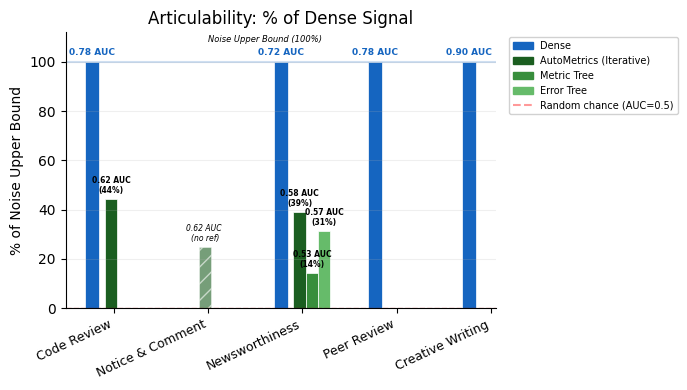


Dataset            Method                          AUC  Signal%
----------------------------------------------------------------
Code Review        AutoMetrics (Iterative)       0.624    44.3%
Newsworthiness     AutoMetrics (Iterative)       0.585    39.2%
Newsworthiness     Metric Tree                   0.531    14.3%
Newsworthiness     Error Tree                    0.568    31.3%


In [73]:
# ── Normalized bar chart (0.5 = 0%, dense = 100%) ──

def plot_signal(df, metric='AUC', chance=0.5, figsize=(8, 5), save_path=None):
    """% of above-chance signal: (val - chance) / (dense - chance) * 100"""
    dense = 'Dense (Llama-8B)'
    artic = [c for c in df.columns if c != dense]
    pal = {
        dense: '#1565C0',
       'AutoMetrics (Iterative)': '#1B5E20', 
       'Metric Tree': '#388E3C',
       'Error Tree': '#66BB6A', 
       'Hypo Gen': '#A5D6A7'
    }
    bw, gap = 0.13, 0.07

    fig, ax = plt.subplots(figsize=figsize)
    for di, ds in enumerate(df.index):
        dv, sig = df.loc[ds, dense], None
        if pd.notna(dv): sig = dv - chance
        dx = di - (len(artic) * bw + gap + bw) / 2 + bw / 2
        if pd.notna(dv):
            ax.bar(dx, 100, bw + 0.02, color=pal[dense], ec='white', lw=.5)
            ax.text(dx, 102, f'{dv:.2f} AUC', ha='center', va='bottom', fontsize=6.5,
                    fontweight='bold', color=pal[dense])
        for ai, m in enumerate(artic):
            v, bx = df.loc[ds, m], dx + bw/2 + gap + ai*bw + bw/2
            if pd.notna(v) and sig and sig > 0:
                pct = max((v - chance) / sig * 100, 0)
                ax.bar(bx, pct, bw, color=pal.get(m, '#999'), ec='white', lw=.5)
                ax.text(bx, pct+1.5, f'{v:.2f} AUC\n({pct:.0f}%)', ha='center', va='bottom', fontsize=5.5, fontweight='bold')
            elif pd.notna(v) and not sig:
                pct = (v - chance) * 200
                ax.bar(bx, pct, bw, color=pal.get(m,'#999'), ec='white', lw=.5, alpha=.6, hatch='//')
                ax.text(bx, pct+1.5, f'{v:.2f} AUC \n(no ref)', ha='center', va='bottom', fontsize=5.5, fontstyle='italic')

    ax.axhline(0, color='red', ls='--', alpha=.4, lw=1)
    ax.axhline(100, color=pal[dense], ls='-', alpha=.2, lw=1.5)
    ax.set(xticks=range(len(df)), ylim=(-5, 118),
           ylabel='% of Noise Upper Bound',
           title=f'Articulability: % of Dense Signal')
    ax.set_xticklabels(df.index, rotation=25, fontsize=9, horizontalalignment='right')
    ax.grid(axis='y', alpha=.2)
    ax.text(x=1, y=108, s= 'Noise Upper Bound (100%)', fontstyle='italic', fontsize=6)
    h = ([mpatches.Patch(color=pal[dense], label='Dense')] +
         [mpatches.Patch(color=pal.get(m,'#999'), label=m) for m in artic] +
         [Line2D([0],[0], color='red', ls='--', alpha=.4, label=f'Random chance ({metric}={chance})')])
    
    ax.legend(handles=h, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, framealpha=.9)
    ax.set_ylim(0, 112)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Print table
    print(f"\n{'Dataset':<18} {'Method':<28} {metric:>6} {'Signal%':>8}")
    print("-" * 64)
    for ds in df.index:
        dv = df.loc[ds, dense]
        if pd.isna(dv): continue
        for m in artic:
            v = df.loc[ds, m]
            if pd.notna(v):
                print(f"{ds:<18} {m:<28} {v:>6.3f} {(v-chance)/(dv-chance)*100:>7.1f}%")

plot_signal(
    df_auc[df_auc.columns.drop('Hypo Gen')].loc[[
    'Code Review',
    'Notice & Comment',
    'Press Releases',
    'Peer Review',
    'Creative Writing'
]].rename(index={'Press Releases': 'Newsworthiness'}), 
    figsize=(7, 4),
    save_path='../notebooks/artifacts/results_normalized_auc.png'
)

In [70]:
df_auc[df_auc.columns.drop('Hypo Gen')].index.tolist()

['Press Releases',
 'Peer Review',
 'Code Review',
 'Notice & Comment',
 'Creative Writing']

In [37]:
# ── Plot 2: Accuracy ──

# Accuracy results (where available)
acc_results = {
    'Press Releases': {
        'Dense (Llama-8B)':          None,  # not reported as accuracy
        'AutoMetrics (Iterative)':   None,
        'Metric Tree':               0.531,
        'Error Tree':                None,
        'Hypo Gen':                  0.604,  # Sheldon: accuracy=0.60375
    },
    'Code Review': {
        'Dense (Llama-8B)':          None,
        'AutoMetrics (Iterative)':   0.650,  # best acc from balanced NC (iter 1)
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
    'Notice & Comment': {
        'Dense (Llama-8B)':          None,
        'AutoMetrics (Iterative)':   0.650,  # best acc iter 1
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
}

df_acc = pd.DataFrame(acc_results).T
df_acc.index.name = 'Dataset'
print("Accuracy results:")
print(df_acc.to_string())
print("\n(Note: accuracy is only meaningful on balanced datasets)")

Accuracy results:
                  Dense (Llama-8B)  AutoMetrics (Iterative)  Metric Tree  Error Tree  Hypo Gen
Dataset                                                                                       
Press Releases                 NaN                      NaN        0.531         NaN     0.604
Code Review                    NaN                     0.65          NaN         NaN       NaN
Notice & Comment               NaN                     0.65          NaN         NaN       NaN

(Note: accuracy is only meaningful on balanced datasets)


In [38]:
# ── Plot 3: Pearson Correlation ──

corr_results = {
    'Press Releases': {
        'Dense (Llama-8B)':          None,
        'AutoMetrics (Iterative)':   None,  # not reported
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  0.222,  # Sheldon: correlation=0.22184
    },
    'Code Review': {
        'Dense (Llama-8B)':          None,
        'AutoMetrics (Iterative)':   0.236,  # best pearson_r (iter 0 on NC, but also code review iter 4 had 0.212)
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
    'Notice & Comment': {
        'Dense (Llama-8B)':          None,
        'AutoMetrics (Iterative)':   0.236,  # best pearson_r iter 0
        'Metric Tree':               None,
        'Error Tree':                None,
        'Hypo Gen':                  None,
    },
}

df_corr = pd.DataFrame(corr_results).T
df_corr.index.name = 'Dataset'
print("Pearson Correlation results:")
print(df_corr.to_string())

Pearson Correlation results:
                  Dense (Llama-8B)  AutoMetrics (Iterative)  Metric Tree  Error Tree  Hypo Gen
Dataset                                                                                       
Press Releases                 NaN                      NaN          NaN         NaN     0.222
Code Review                    NaN                    0.236          NaN         NaN       NaN
Notice & Comment               NaN                    0.236          NaN         NaN       NaN


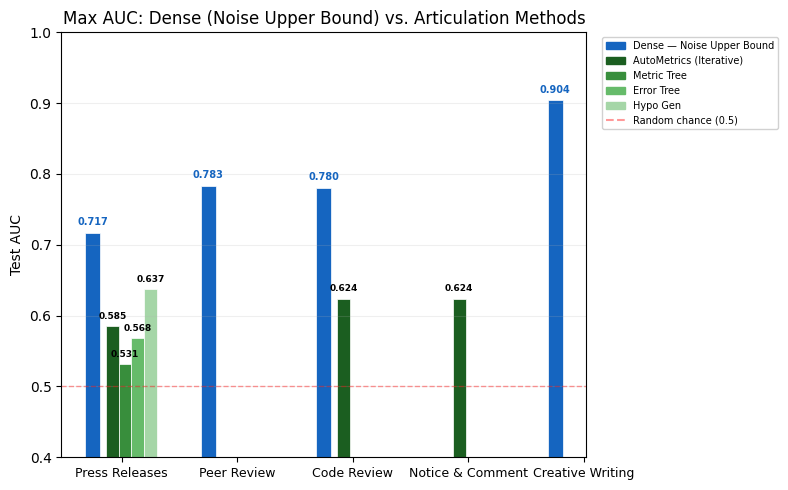

In [39]:
# ── Raw AUC grouped bar ──

def plot_raw(df, metric='AUC', figsize=(8, 5), save_path=None):
    """Raw AUC with dense separated from articulation methods (green shades)."""
    dense = 'Dense (Llama-8B)'
    artic = [c for c in df.columns if c != dense]
    pal = {dense: '#1565C0',
           'AutoMetrics (Iterative)': '#1B5E20', 'Metric Tree': '#388E3C',
           'Error Tree': '#66BB6A', 'Hypo Gen': '#A5D6A7'}
    bw, gap = 0.11, 0.06

    fig, ax = plt.subplots(figsize=figsize)
    for di, ds in enumerate(df.index):
        dv = df.loc[ds, dense]
        dx = di - (len(artic) * bw + gap + bw) / 2 + bw / 2
        if pd.notna(dv):
            ax.bar(dx, dv, bw + 0.02, color=pal[dense], ec='white', lw=.5)
            ax.text(dx, dv + .008, f'{dv:.3f}', ha='center', va='bottom',
                    fontsize=7, fontweight='bold', color=pal[dense])
        for ai, m in enumerate(artic):
            v, bx = df.loc[ds, m], dx + bw/2 + gap + ai*bw + bw/2
            if pd.notna(v):
                ax.bar(bx, v, bw, color=pal.get(m, '#999'), ec='white', lw=.5)
                ax.text(bx, v + .008, f'{v:.3f}', ha='center', va='bottom',
                        fontsize=6.5, fontweight='bold')

    ax.axhline(.5, color='red', ls='--', alpha=.4, lw=1)
    ax.set(xticks=range(len(df)), ylim=(0.4, 1.0),
           ylabel=f'Test {metric}',
           title=f'Max {metric}: Dense (Noise Upper Bound) vs. Articulation Methods')
    ax.set_xticklabels(df.index, fontsize=9)
    ax.grid(axis='y', alpha=.2)
    h = ([mpatches.Patch(color=pal[dense], label='Dense — Noise Upper Bound')] +
         [mpatches.Patch(color=pal.get(m,'#999'), label=m) for m in artic] +
         [Line2D([0],[0], color='red', ls='--', alpha=.4, label='Random chance (0.5)')])
    ax.legend(handles=h, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, framealpha=.9)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_raw(df_auc, save_path='../notebooks/artifacts/results_raw_auc.png')

In [40]:
# ── Detailed Results Table ──

print("=" * 90)
print("DETAILED RESULTS")
print("=" * 90)
print()

details = [
    ('Press Releases', 'Dense (Llama-8B)', 0.717, None, None, 'Subset=0.8, 3 trials'),
    ('Press Releases', 'AutoMetrics (Iterative)', 0.585, None, None, '25 iters, best iter 17'),
    ('Press Releases', 'Metric Tree', 0.531, 0.531, None, 'Root node only'),
    ('Press Releases', 'Error Tree', 0.568, None, None, 'GPT-5-mini, error-only'),
    ('Press Releases', 'Hypo Gen', 0.637, 0.604, 0.222, 'Sheldon, nested CV'),
    ('Peer Review', 'Dense (Llama-8B)', 0.783, None, None, 'Subset=0.8, 5 trials'),
    ('Code Review', 'Dense (Llama-8B)', 0.780, None, None, 'Subset=0.5, 141K PRs'),
    ('Code Review', 'AutoMetrics (Iterative)', 0.624, 0.650, 0.236, 'Balanced, best iter 1-2'),
    ('Notice & Comment', 'AutoMetrics (Iterative)', 0.624, 0.650, 0.236, 'Balanced 50/50, best iter 0-1'),
    ('Creative Writing', 'Dense (Llama-8B)', 0.904, None, None, 'Subset=1.0, still climbing'),
]

detail_df = pd.DataFrame(details, columns=['Dataset', 'Method', 'AUC', 'Accuracy', 'Pearson r', 'Notes'])
print(detail_df.to_string(index=False))
print()
print("\nSheldon's full results (press-releases, nested cross-validation):")
for k, v in sheldon_full.items():
    print(f"  {k}: {v}")

DETAILED RESULTS

         Dataset                  Method   AUC  Accuracy  Pearson r                         Notes
  Press Releases        Dense (Llama-8B) 0.717       NaN        NaN          Subset=0.8, 3 trials
  Press Releases AutoMetrics (Iterative) 0.585       NaN        NaN        25 iters, best iter 17
  Press Releases             Metric Tree 0.531     0.531        NaN                Root node only
  Press Releases              Error Tree 0.568       NaN        NaN        GPT-5-mini, error-only
  Press Releases                Hypo Gen 0.637     0.604      0.222            Sheldon, nested CV
     Peer Review        Dense (Llama-8B) 0.783       NaN        NaN          Subset=0.8, 5 trials
     Code Review        Dense (Llama-8B) 0.780       NaN        NaN          Subset=0.5, 141K PRs
     Code Review AutoMetrics (Iterative) 0.624     0.650      0.236       Balanced, best iter 1-2
Notice & Comment AutoMetrics (Iterative) 0.624     0.650      0.236 Balanced 50/50, best iter 0-1
Cr

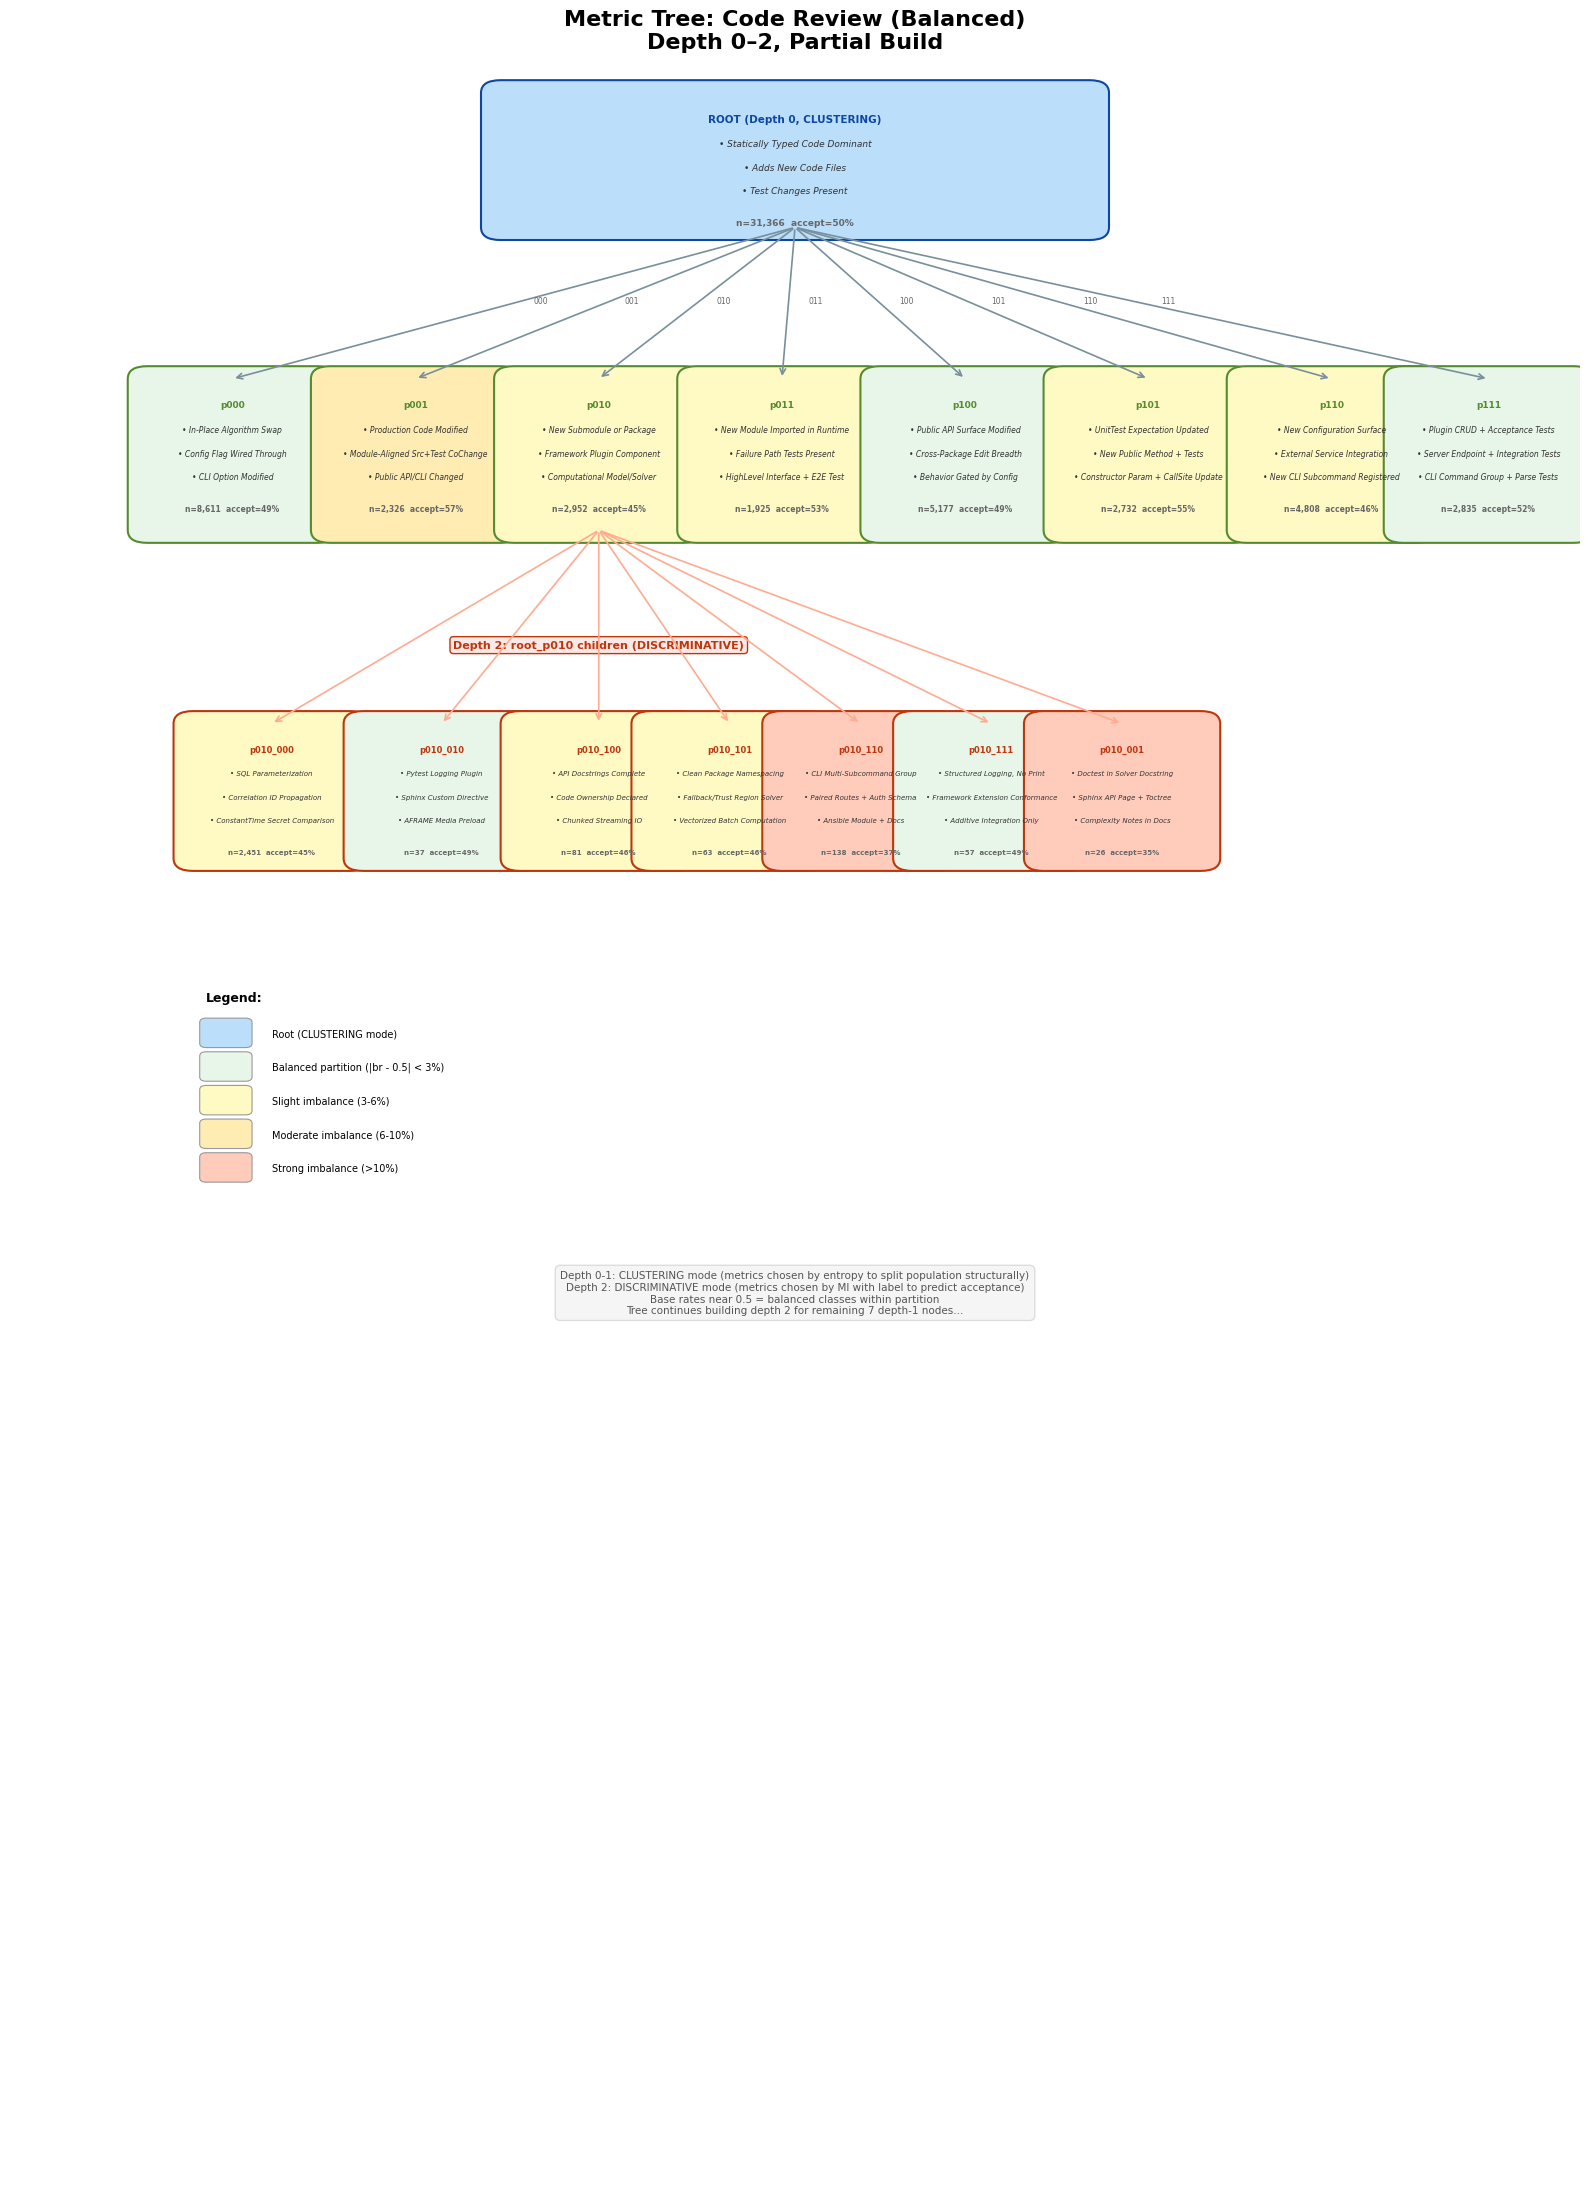

In [41]:
# ── Metric Tree Visualization (Code Review, Balanced, Partial Depth 2) ──

import matplotlib.pyplot as plt
import matplotlib.patches as FancyBboxPatch
from matplotlib.patches import FancyBboxPatch as FBP

fig, ax = plt.subplots(figsize=(16, 22))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 24)
ax.axis('off')
ax.set_title('Metric Tree: Code Review (Balanced)\nDepth 0–2, Partial Build', 
             fontsize=16, fontweight='bold', pad=20)

def draw_node(ax, x, y, w, h, title, metrics, n, br, color='#E3F2FD', border='#1565C0', fontsize=6.5):
    """Draw a rounded box with node info."""
    box = FBP((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.15",
              facecolor=color, edgecolor=border, linewidth=1.5)
    ax.add_patch(box)
    # Title
    ax.text(x, y + h/2 - 0.25, title, ha='center', va='top',
            fontsize=fontsize + 1, fontweight='bold', color=border)
    # Metrics (shortened)
    metric_y = y + h/2 - 0.55
    for i, m in enumerate(metrics[:3]):
        short = m.replace('_', ' ')
        if len(short) > 35:
            short = short[:33] + '...'
        ax.text(x, metric_y - i * 0.28, f'• {short}', ha='center', va='top',
                fontsize=fontsize, color='#333', fontstyle='italic')
    # Stats
    stats_y = metric_y - len(metrics[:3]) * 0.28 - 0.1
    accept_pct = f'{br*100:.0f}%' if br else '?'
    ax.text(x, stats_y, f'n={n:,}  accept={accept_pct}', ha='center', va='top',
            fontsize=fontsize, color='#666', fontweight='bold')

def draw_edge(ax, x1, y1, x2, y2, label='', color='#90A4AE'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.15, my, label, fontsize=5.5, color='#666', rotation=0)

# ══════════════════════════════════════════════
# DEPTH 0 — ROOT
# ══════════════════════════════════════════════
draw_node(ax, 5, 23, 4.5, 1.6, 'ROOT (Depth 0, CLUSTERING)',
          ['Statically Typed Code Dominant',
           'Adds New Code Files', 
           'Test Changes Present'],
          31366, 0.50, color='#BBDEFB', border='#0D47A1')

# ══════════════════════════════════════════════
# DEPTH 1 — 8 partitions (BFS)
# ══════════════════════════════════════════════
d1_nodes = [
    # (key, x, metrics, n, br)
    ('000', 0.7, ['In-Place Algorithm Swap', 'Config Flag Wired Through', 'CLI Option Modified'], 8611, 0.493),
    ('001', 2.1, ['Production Code Modified', 'Module-Aligned Src+Test CoChange', 'Public API/CLI Changed'], 2326, 0.572),
    ('010', 3.5, ['New Submodule or Package', 'Framework Plugin Component', 'Computational Model/Solver'], 2952, 0.448),
    ('011', 4.9, ['New Module Imported in Runtime', 'Failure Path Tests Present', 'HighLevel Interface + E2E Test'], 1925, 0.531),
    ('100', 6.3, ['Public API Surface Modified', 'Cross-Package Edit Breadth', 'Behavior Gated by Config'], 5177, 0.490),
    ('101', 7.7, ['UnitTest Expectation Updated', 'New Public Method + Tests', 'Constructor Param + CallSite Update'], 2732, 0.550),
    ('110', 9.1, ['New Configuration Surface', 'External Service Integration', 'New CLI Subcommand Registered'], 4808, 0.465),
    ('111', 10.3, ['Plugin CRUD + Acceptance Tests', 'Server Endpoint + Integration Tests', 'CLI Command Group + Parse Tests'], 2835, 0.525),
]

d1_y = 19.5
for key, x, metrics, n, br in d1_nodes:
    # Color by base rate deviation from 0.5
    dev = abs(br - 0.5)
    if dev < 0.03:
        c = '#E8F5E9'  # very balanced = green
    elif dev < 0.06:
        c = '#FFF9C4'  # slight imbalance = yellow
    else:
        c = '#FFECB3'  # more imbalanced = amber
    draw_node(ax, x, d1_y, 1.3, 1.8, f'p{key}', metrics, n, br,
              color=c, border='#558B2F', fontsize=5.5)
    draw_edge(ax, 5, 23 - 0.8, x, d1_y + 0.9, label=key, color='#78909C')

# ══════════════════════════════════════════════
# DEPTH 2 — root_p010 children (completed)
# ══════════════════════════════════════════════
ax.text(3.5, 17.2, 'Depth 2: root_p010 children (DISCRIMINATIVE)', 
        ha='center', fontsize=8, fontweight='bold', color='#BF360C',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FBE9E7', edgecolor='#BF360C'))

d2_p010 = [
    ('000', 1.0, ['SQL Parameterization', 'Correlation ID Propagation', 'ConstantTime Secret Comparison'], 2451, 0.451),
    ('010', 2.3, ['Pytest Logging Plugin', 'Sphinx Custom Directive', 'AFRAME Media Preload'], 37, 0.486),
    ('100', 3.5, ['API Docstrings Complete', 'Code Ownership Declared', 'Chunked Streaming IO'], 81, 0.463),
    ('101', 4.5, ['Clean Package Namespacing', 'Fallback/Trust Region Solver', 'Vectorized Batch Computation'], 63, 0.460),
    ('110', 5.5, ['CLI Multi-Subcommand Group', 'Paired Routes + Auth Schema', 'Ansible Module + Docs'], 138, 0.370),
    ('111', 6.5, ['Structured Logging, No Print', 'Framework Extension Conformance', 'Additive Integration Only'], 57, 0.491),
    ('001', 7.5, ['Doctest in Solver Docstring', 'Sphinx API Page + Toctree', 'Complexity Notes in Docs'], 26, 0.346),
]

d2_y = 15.5
for key, x, metrics, n, br in d2_p010:
    dev = abs(br - 0.5)
    if dev < 0.03:
        c = '#E8F5E9'
    elif dev < 0.06:
        c = '#FFF9C4'
    elif dev < 0.1:
        c = '#FFECB3'
    else:
        c = '#FFCCBC'  # strongly imbalanced = red-ish
    draw_node(ax, x, d2_y, 1.2, 1.6, f'p010_{key}', metrics, n, br,
              color=c, border='#BF360C', fontsize=5)
    draw_edge(ax, 3.5, d1_y - 0.9, x, d2_y + 0.8, color='#FFAB91')

# ══════════════════════════════════════════════
# LEGEND
# ══════════════════════════════════════════════
legend_y = 13.0
ax.text(0.5, legend_y, 'Legend:', fontsize=9, fontweight='bold')
for i, (color, label) in enumerate([
    ('#BBDEFB', 'Root (CLUSTERING mode)'),
    ('#E8F5E9', 'Balanced partition (|br - 0.5| < 3%)'),
    ('#FFF9C4', 'Slight imbalance (3-6%)'),
    ('#FFECB3', 'Moderate imbalance (6-10%)'),
    ('#FFCCBC', 'Strong imbalance (>10%)'),
]):
    box = FBP((0.5, legend_y - 0.5 - i*0.4), 0.3, 0.25, boxstyle="round,pad=0.05",
              facecolor=color, edgecolor='#999', linewidth=0.8)
    ax.add_patch(box)
    ax.text(1.0, legend_y - 0.38 - i*0.4, label, fontsize=7, va='center')

ax.text(5, legend_y - 3.2, 
        'Depth 0-1: CLUSTERING mode (metrics chosen by entropy to split population structurally)\n'
        'Depth 2: DISCRIMINATIVE mode (metrics chosen by MI with label to predict acceptance)\n'
        'Base rates near 0.5 = balanced classes within partition\n'
        'Tree continues building depth 2 for remaining 7 depth-1 nodes...',
        fontsize=7.5, ha='center', va='top', color='#555',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', edgecolor='#DDD'))

plt.tight_layout()
plt.savefig('../notebooks/artifacts/metric_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()